# Analiza comparativă a modelelor de clasificare pentru predicția riscului de boală cardiacă

## 1. Definirea problemei

În acest notebook este analizată o problemă de clasificare binară, având ca scop predicția prezenței bolii cardiace pe baza unor caracteristici clinice și demografice ale pacienților.

Variabila țintă este `target`, iar variabilele de intrare descriu informații precum vârsta, sexul, tipul durerii toracice, tensiunea arterială în repaus, colesterolul și alți indicatori medicali relevanți.

Problema are relevanță practică deoarece astfel de date pot fi folosite pentru identificarea mai rapidă a pacienților cu risc crescut. Un model de machine learning nu înlocuiește decizia medicală, dar poate funcționa ca instrument în evaluarea inițială a riscului.

Am ales acest set de date deoarece este potrivit pentru analiza comparativă între mai mulți algoritmi de clasificare și permite atât evaluarea performanței, cât și interpretarea rezultatelor.

Valorile varibilei țintă sunt:
- `0` - absența bolii cardiace
- `1` - prezența bolii cardiace

## 2. Obiectivul analizei

Scopul analizei este antrenarea, evaluarea și compararea mai multor modele de clasificare pentru predicția variabilei `target`. Vor fi analizate atât performanțele modelelor de bază, cât și versiunile avansate ale celor mai bune modele, folosind metrici specifice clasificării, curbe de învățare și tehnici de explicabilitate.

## 3. Încărcarea și inspectarea inițială a datelor

In [17]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [18]:
df = pd.read_csv("../data/raw/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [19]:
print("Shape:",df.shape)

display(df.info())

print("\nValori lipsa:")
display(df.isnull().sum())

print("\nLinii duplicate:", df.duplicated().sum())

Shape: (1025, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None


Valori lipsa:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Linii duplicate: 723


In [20]:
print("Distributia claselor:")
display(df["target"].value_counts().sort_index())

print("\nDistributia procentuala:")
display((df["target"].value_counts(normalize=True).sort_index() * 100).round(2))

display(df.describe().T)

Distributia claselor:


target
0    499
1    526
Name: count, dtype: int64


Distributia procentuala:


target
0   48.680
1   51.320
Name: proportion, dtype: float64

,count,mean,std,min,25%,50%,75%,max
age,1025.000,54.434,9.072,29.000,48.000,56.000,61.000,77.000
sex,1025.000,0.696,0.460,0.000,0.000,1.000,1.000,1.000
cp,1025.000,0.942,1.030,0.000,0.000,1.000,2.000,3.000
trestbps,1025.000,131.612,17.517,94.000,120.000,130.000,140.000,200.000
chol,1025.000,246.000,51.593,126.000,211.000,240.000,275.000,564.000
fbs,1025.000,0.149,0.357,0.000,0.000,0.000,0.000,1.000
restecg,1025.000,0.530,0.528,0.000,0.000,1.000,1.000,2.000
thalach,1025.000,149.114,23.006,71.000,132.000,152.000,166.000,202.000
exang,1025.000,0.337,0.473,0.000,0.000,0.000,1.000,1.000
oldpeak,1025.000,1.072,1.175,0.000,0.000,0.800,1.800,6.200


### Observații

Datele nu conțin valori lipsă, iar distribuția claselor este una echilibrată. Totuși,exixtența unui număr mare de duplicată indică faptul că este nevoie de o etapă de curățare a setului de date înainte de modelare.

## 4. Curățarea datelor și analiza exploratorie

In [21]:
initial_shape = df.shape

df = df.drop_duplicates().reset_index(drop=True)

print("Forma initiala:", initial_shape)
print("Forma dupa eliminarea duplicatelor:", df.shape)
print("Duplicate ramase:", df.duplicated().sum())

Forma initiala: (1025, 14)
Forma dupa eliminarea duplicatelor: (302, 14)
Duplicate ramase: 0


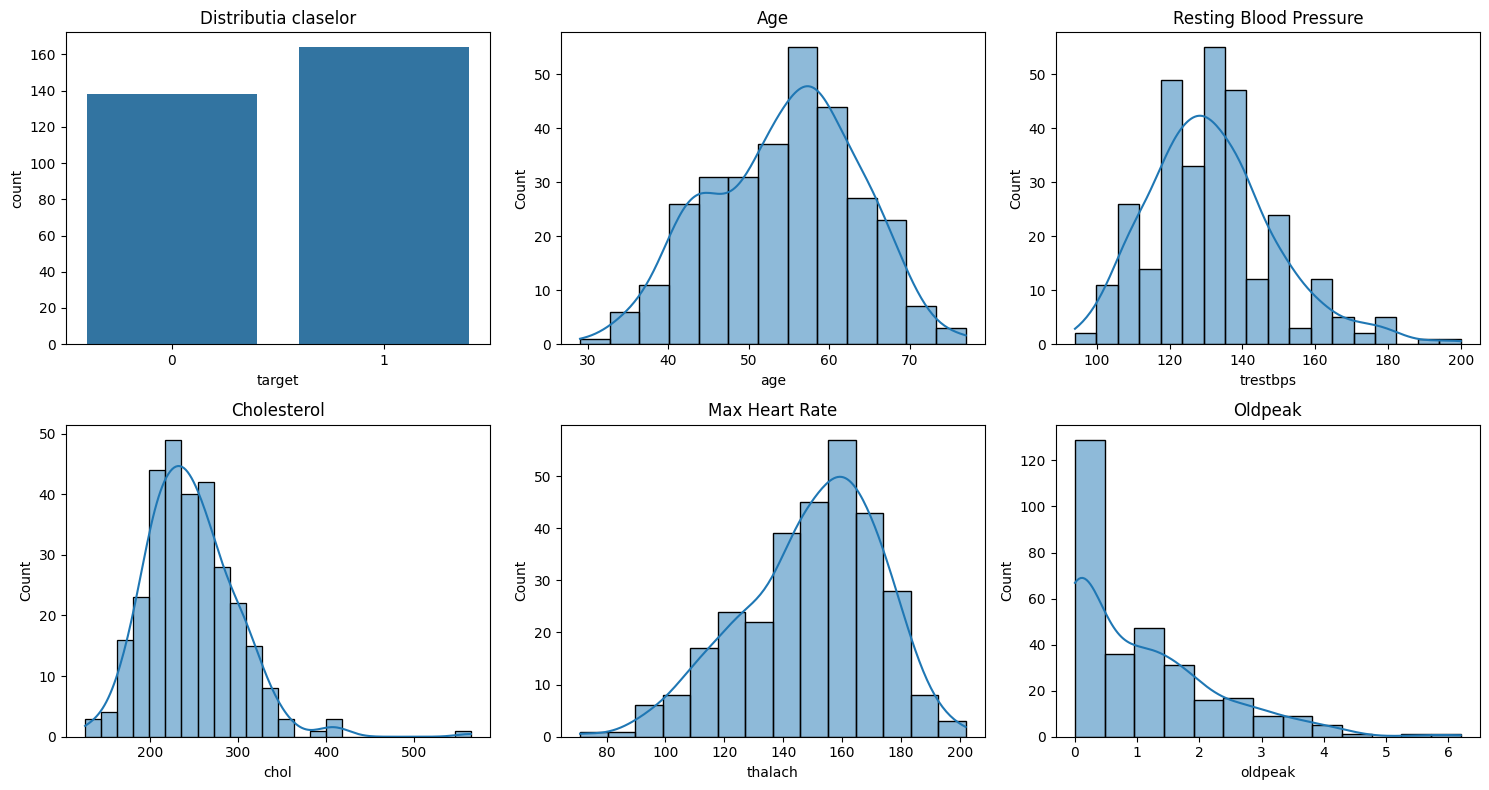

In [23]:
fig, axes=plt.subplots(2, 3, figsize=(15,8))

sns.countplot(data=df, x="target", ax=axes[0, 0])
axes[0, 0].set_title("Distributia claselor")

sns.histplot(df["age"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Age")

sns.histplot(df["trestbps"], kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Resting Blood Pressure")

sns.histplot(df["chol"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Cholesterol")

sns.histplot(df["thalach"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Max Heart Rate")

sns.histplot(df["oldpeak"], kde=True, ax=axes[1, 2])
axes[1, 2].set_title("Oldpeak")

plt.tight_layout()
plt.show()

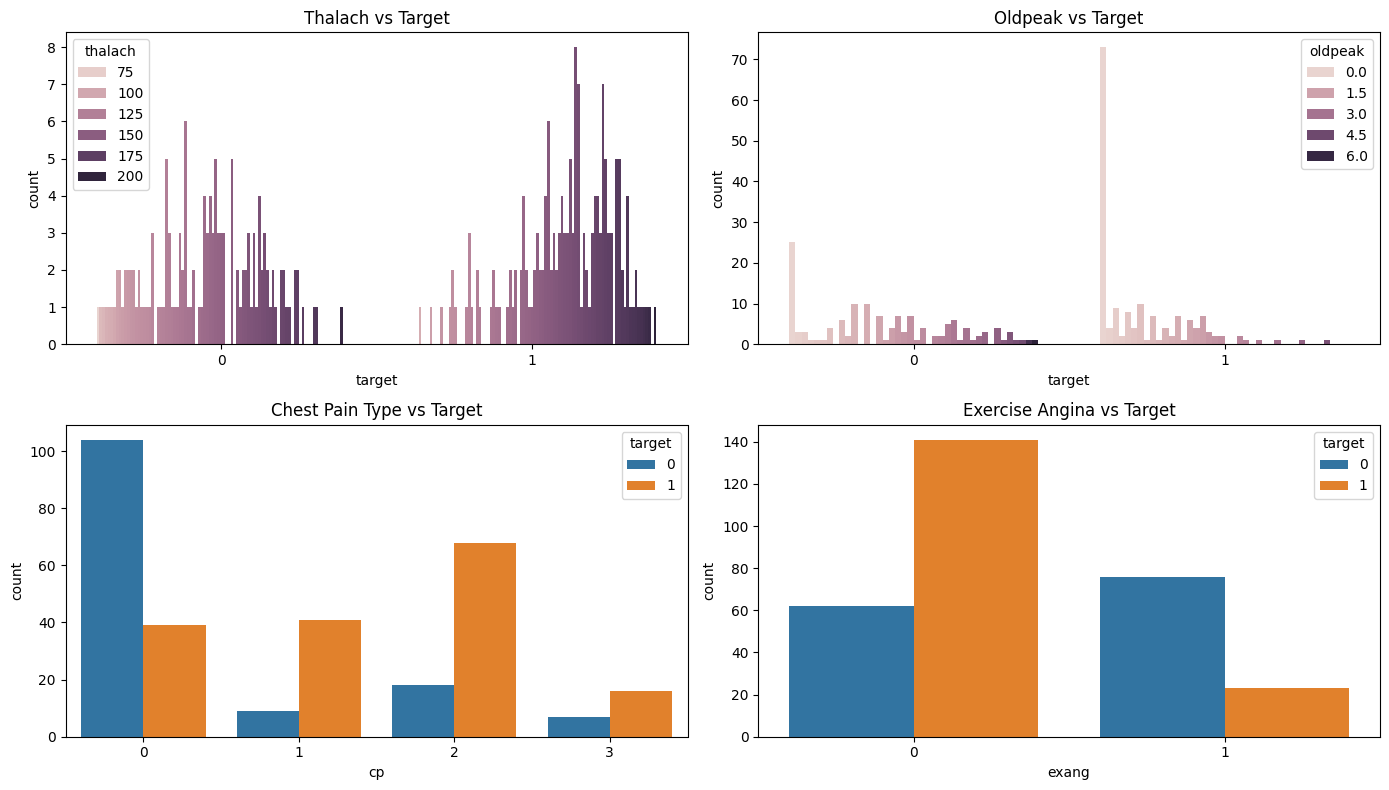

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.countplot(data=df, x="target", hue="thalach", ax=axes[0, 0])
axes[0, 0].set_title("Thalach vs Target")

sns.countplot(data=df, x="target", hue="oldpeak", ax=axes[0, 1])
axes[0, 1].set_title("Oldpeak vs Target")

sns.countplot(data=df, x="cp", hue="target", ax=axes[1, 0])
axes[1, 0].set_title("Chest Pain Type vs Target")

sns.countplot(data=df, x="exang", hue="target", ax=axes[1, 1])
axes[1, 1].set_title("Exercise Angina vs Target")

plt.tight_layout()
plt.show()

### Observții

După eliminarea duplicatelor, setul de date rămâne echilibrat din punctul de vedere al claselor. Variabile precum `thalach`, `oldpeak`, `cp` și `exang` par a fi relevante pentru variabila țintă.

## 5. Pregătirea datelor pentru modelare

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

Train set: (226, 13)
Test set: (76, 13)


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
print("Train target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution:")
print((y_test.value_counts(normalize=True) * 100).round())

Train target distribution:
target
1   54.420
0   45.580
Name: proportion, dtype: float64

Test target distribution:
target
1   54.000
0   46.000
Name: proportion, dtype: float64


### Observații

Datele au fost împărțite în proporție de 75% pentru antrenare și 25% pentru testare, folosind stratificare pentru păstrarea distribuției claselor. Am făcut și o versiune standardizată a caracteristicilor, necesară pentru algoritmiii sensibili la scalarea datelor, precum Logistic Regession, KNN și SVM. Pentru modelele bazate pe arbori au fost păstrate și datele în formă originală, deoarece acestea nu necesită scalare.

## 6. Antrenarea modelelor de bază
### 6.1 Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression

results = []

log_reg = LogisticRegression(max_iter=2000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:,1]

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
}

results.append(lr_results)
pd.DataFrame([lr_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803,0.783,0.878,0.828,0.875


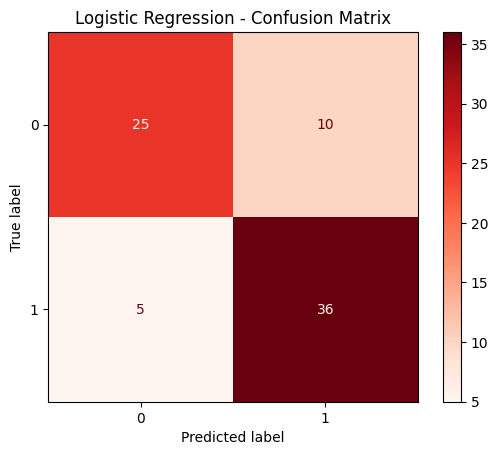

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

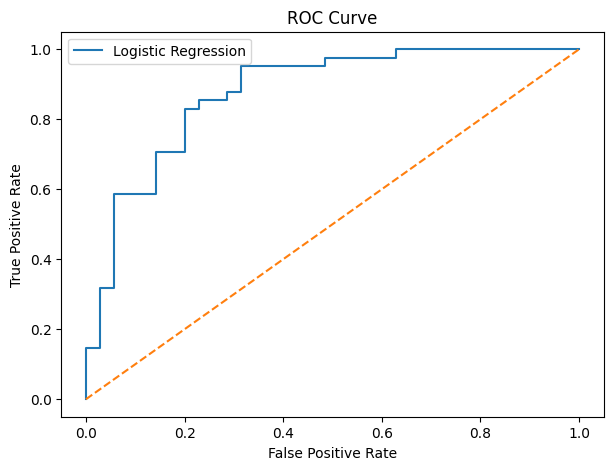

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Logistic Regression oferă un punct de referință foarte bun pentru viitoarele comparații. Fiind un model liniar, rezultatele sale sunt utile pentru a evalua dacă relația dintre caracteristici și variabila țintă poate fi observată eficient fără metode mai complexe.

### 6.2 Gaussian Naive Bayes

In [37]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)

y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:,1]

In [48]:
gnb_results = {
    "Model": "Gaussian Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_gnb),
    "Precision": precision_score(y_test, y_pred_gnb),
    "Recall": recall_score(y_test, y_pred_gnb),
    "F1 Score": f1_score(y_test, y_pred_gnb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_gnb)
}

results.append(gnb_results)
pd.DataFrame([gnb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gaussian Naive Bayes,0.803,0.842,0.780,0.810,0.880


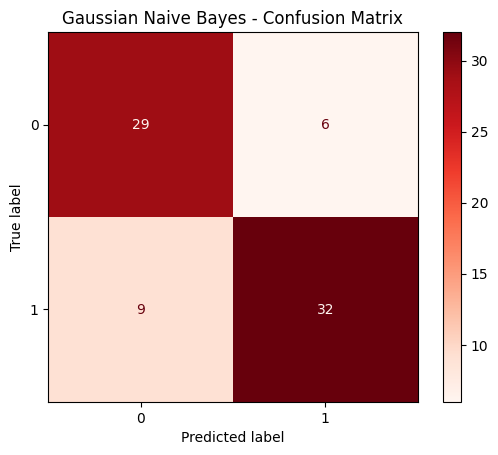

In [43]:
cm = confusion_matrix(y_test, y_pred_gnb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.show()

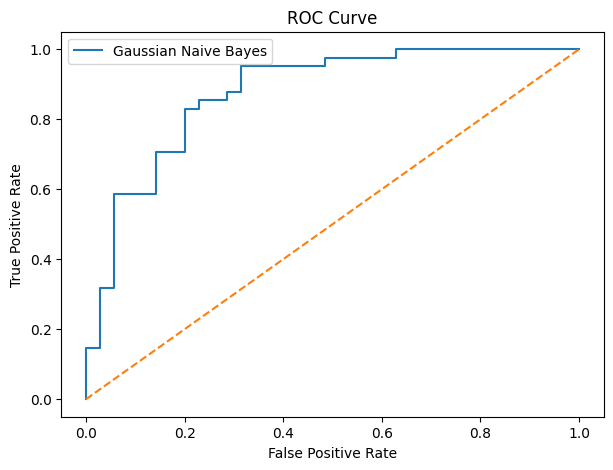

In [45]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Gaussian Naive Bayes")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Gaussian Naive Bayes este un model eficient și foarte rapid, util ca punct de comparație pentru algoritmii mai complecși. Peformanța sa depinde de cât de bine sunt respectate principiile de independență între caracteristici.

### 6.3 K-Nearest Neighbors (KNN)

In [50]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:,1]

In [51]:
knn_results = {
    "Model": "K-Nearest Neighbors",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1 Score": f1_score(y_test, y_pred_knn),
    "ROC-AUC": roc_auc_score(y_test, y_prob_knn)
}

results.append(knn_results)
pd.DataFrame([knn_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,K-Nearest Neighbors,0.789,0.791,0.829,0.809,0.829


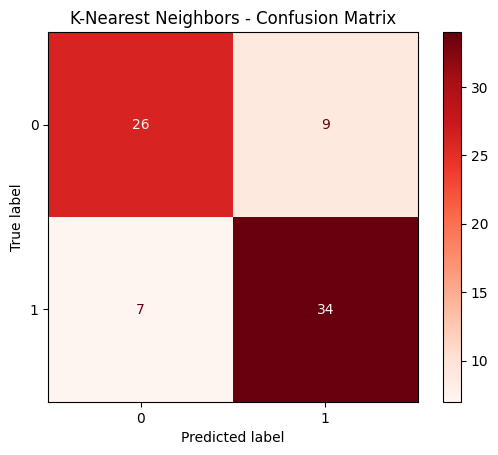

In [52]:
cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("K-Nearest Neighbors - Confusion Matrix")
plt.show()

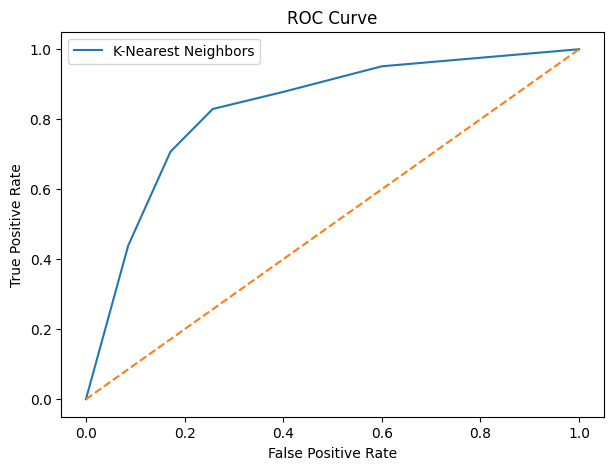

In [53]:
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="K-Nearest Neighbors")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
K-Nearest Neighbors clasifică observațiile pe baza celor mai apropriați vecini din setul de antrenare. Modelul este sensibil la scalarea datelor, motiv pentru care a fost antrenat pe varianta standardizată a caracteristicilor.

### 6.4 Support Vector Machine (SVM)

In [58]:
from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

In [55]:
svm_results = {
    "Model": "Support Vector Machine",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1 Score": f1_score(y_test, y_pred_svm),
    "ROC-AUC": roc_auc_score(y_test, y_prob_svm)
}

results.append(svm_results)
pd.DataFrame([svm_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Support Vector Machine,0.789,0.791,0.829,0.809,0.845


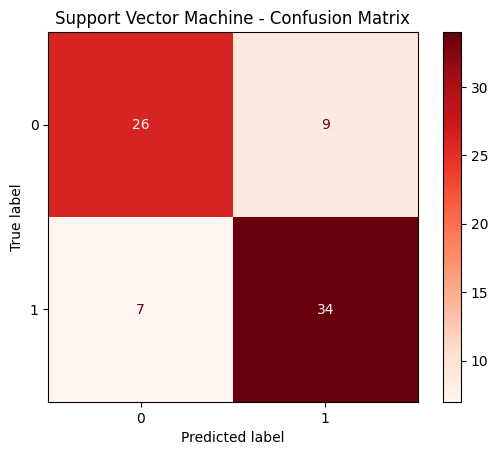

In [56]:
cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Support Vector Machine - Confusion Matrix")
plt.show()

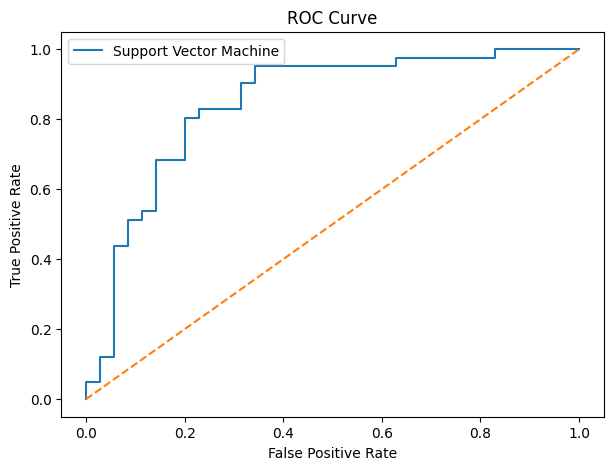

In [57]:
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Support Vector Machine")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Support Vector Machine urmărește separarea optimă a claselor printr-o frontieră de decizie cu marjă maximă. Modelul este, de asemenea, sensibil la scalarea caracteristicilor, astfel antrenarea a fost făcută pe date standardizate.

### 6.5 Decision Tree

In [59]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [60]:
dt_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
}

results.append(dt_results)
pd.DataFrame([dt_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.724,0.738,0.756,0.747,0.721


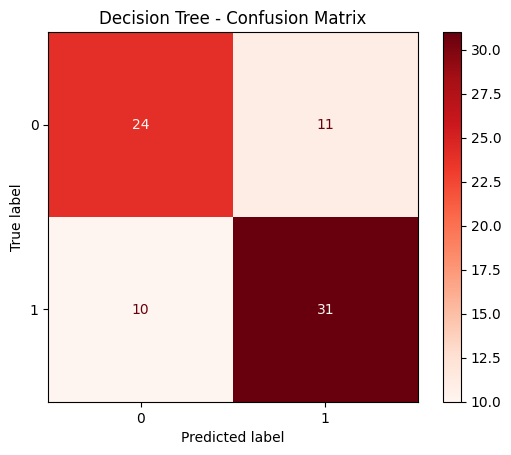

In [61]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

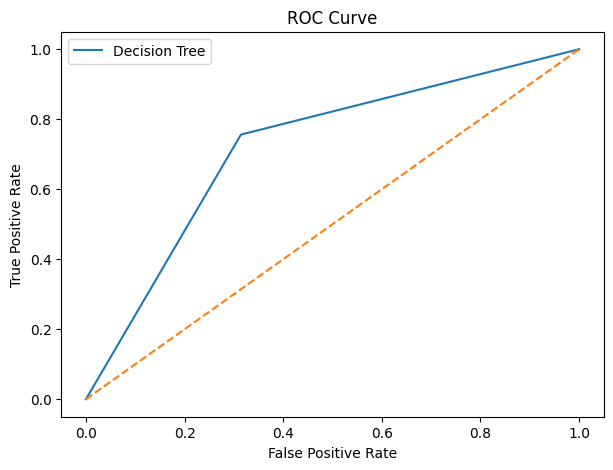

In [62]:
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Decision Tree construiește reguli de decizie pe baza caracteristicilor disponibile. Modelul nu necesită standardizarea datelor, însă poate fi predispus la overfitting în forma sa de bază.

### 6.6 Random Forest

In [63]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(random_state=42)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [64]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
}

results.append(rf_results)
pd.DataFrame([rf_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.803,0.809,0.829,0.819,0.854


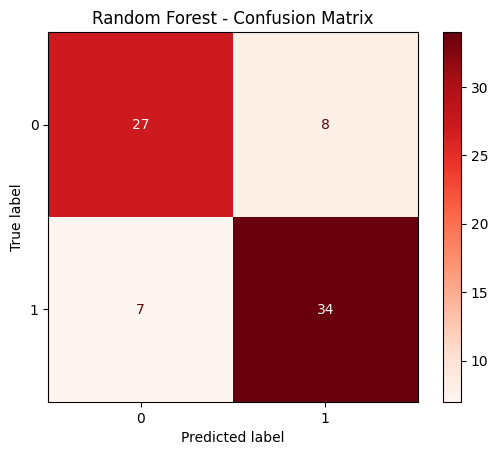

In [65]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Random Forest - Confusion Matrix")
plt.show()

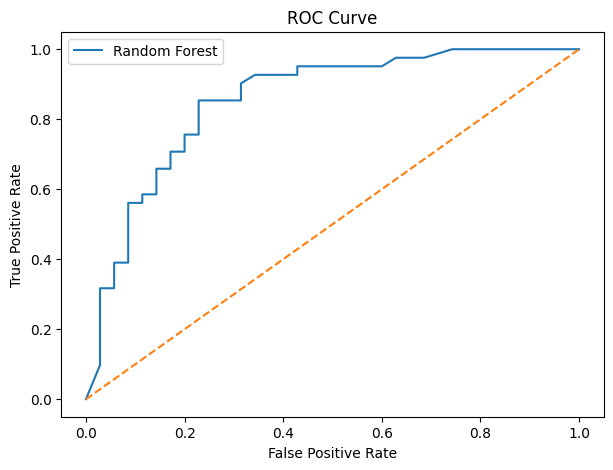

In [66]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Random Forest combină mai mulți arbori de decizie antrenați pe eșantioane diferite ale datelor, reducând riscul de overfitting specific unui singur arbore. În practică, este adesea unul dintre cele mai stabile modele pentru date tabelare.

### 6.7 Xtreme Gradient Boosting (XGBoost)

In [68]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(eval_metric="logloss",random_state=42)

xgboost_model.fit(X_train, y_train)

y_pred_xgb = xgboost_model.predict(X_test)
y_prob_xgb = xgboost_model.predict_proba(X_test)[:, 1]

In [69]:
xgb_results = {
    "Model": "Xtreme Gradient Boosting",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
}

results.append(xgb_results)
pd.DataFrame([xgb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Xtreme Gradient Boosting,0.750,0.762,0.780,0.771,0.854


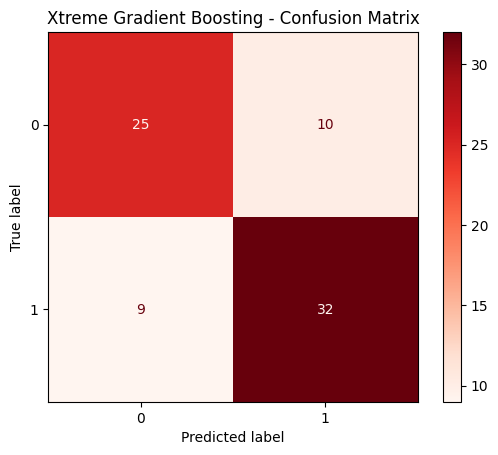

In [70]:
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Xtreme Gradient Boosting - Confusion Matrix")
plt.show()

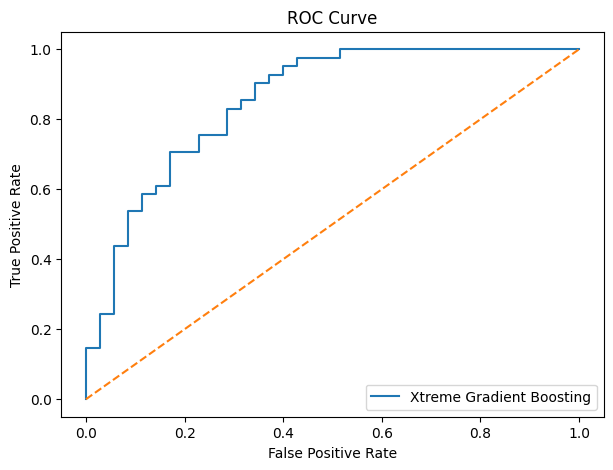

In [71]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Xtreme Gradient Boosting")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații 
Xtreme Gradient Boosting construiește succesiv arbori de decizie, fiecare model nou încercând să corecteze erorile celor anterioare. Este un algoritm puternic pentru date tabelare și poate obține performanțe foarte bune chiar și cu setări implicite.

### 6.8 Categorical Boosting (CatBoost)

In [72]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(verbose=0, random_state=42)

catboost_model.fit(X_train, y_train)

y_pred_cat = catboost_model.predict(X_test)
y_prob_cat = catboost_model.predict_proba(X_test)[:, 1]

y_pred_cat = y_pred_cat.astype(int)

In [73]:
cat_results = {
    "Model": "Categorical Boosting",
    "Accuracy": accuracy_score(y_test, y_pred_cat),
    "Precision": precision_score(y_test, y_pred_cat),
    "Recall": recall_score(y_test, y_pred_cat),
    "F1 Score": f1_score(y_test, y_pred_cat),
    "ROC-AUC": roc_auc_score(y_test, y_prob_cat)
}

results.append(cat_results)
pd.DataFrame([cat_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Categorical Boosting,0.776,0.773,0.829,0.800,0.868


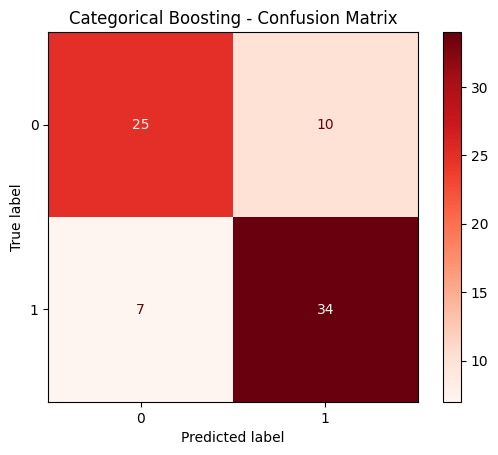

In [74]:
cm = confusion_matrix(y_test, y_pred_cat)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Categorical Boosting - Confusion Matrix")
plt.show()

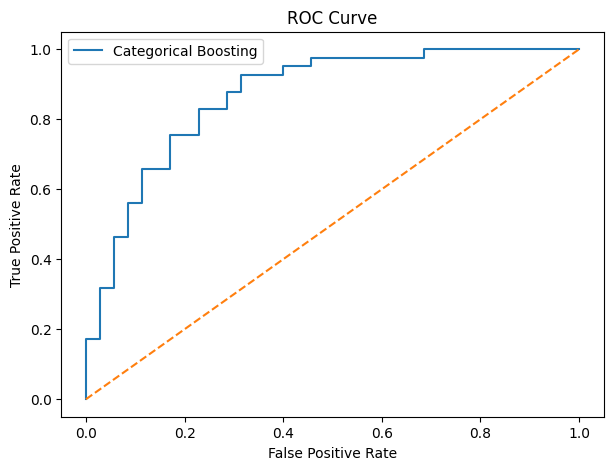

In [75]:
fpr, tpr, _ = roc_curve(y_test, y_prob_cat)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Categorical Boosting")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Categorical Boosting este un algoritm de boosting modern, făcut pentru performanță ridicată pe date tabelare. Deși este cunoscut pentru tratarea eficientă a variabilelor categoriale, poate oferi rezultate foarte bune și pe seturi de date deja numerice.

### 6.9 Explainable Boosting Machine (EBM)

In [76]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm_model = ExplainableBoostingClassifier(random_state=42)

ebm_model.fit(X_train, y_train)

y_pred_ebm = ebm_model.predict(X_test)
y_prob_ebm = ebm_model.predict_proba(X_test)[:, 1]

In [77]:
ebm_results = {
    "Model": "Explainable Boosting Machine",
    "Accuracy": accuracy_score(y_test, y_pred_ebm),
    "Precision": precision_score(y_test, y_pred_ebm),
    "Recall": recall_score(y_test, y_pred_ebm),
    "F1 Score": f1_score(y_test, y_pred_ebm),
    "ROC-AUC": roc_auc_score(y_test, y_prob_ebm)
}

results.append(ebm_results)
pd.DataFrame([ebm_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Explainable Boosting Machine,0.803,0.825,0.805,0.815,0.884


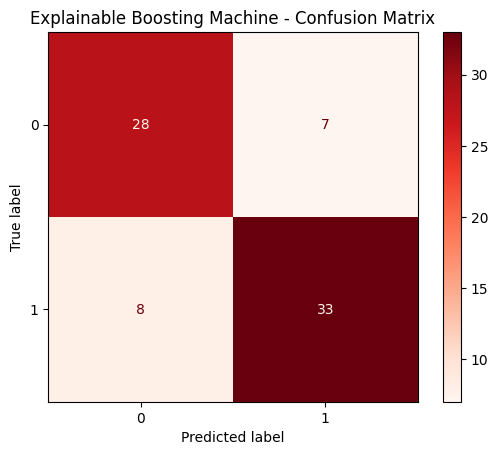

In [79]:
cm = confusion_matrix(y_test, y_pred_ebm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Explainable Boosting Machine - Confusion Matrix")
plt.show()

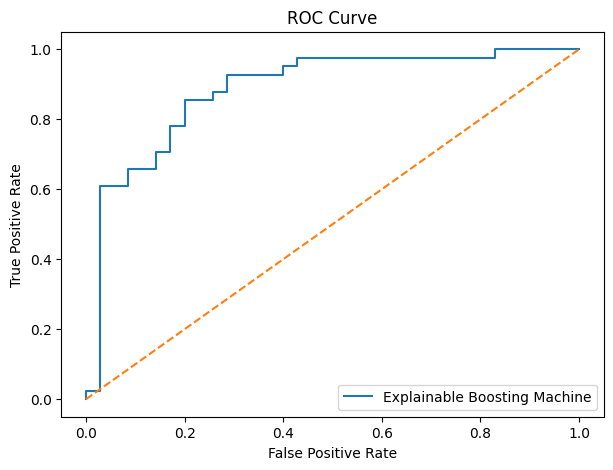

In [80]:
fpr, tpr, _ = roc_curve(y_test, y_prob_ebm)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Explainable Boosting Machine")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Explainable Boosting Machine combină performanța modelelor de boosting cu un nivel ridicat de interpretabilitate. Modelul este util în contexte în care acuratețea trebuie completată de probabilitatea explicării deciziilor.

## 7. Compararea modelelor de bază

In [81]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Explainable Boosting Machine,0.803,0.825,0.805,0.815,0.884
1,Gaussian Naive Bayes,0.803,0.842,0.780,0.810,0.880
2,Logistic Regression,0.803,0.783,0.878,0.828,0.875
3,Categorical Boosting,0.776,0.773,0.829,0.800,0.868
4,Xtreme Gradient Boosting,0.750,0.762,0.780,0.771,0.854
5,Random Forest,0.803,0.809,0.829,0.819,0.854
6,Support Vector Machine,0.789,0.791,0.829,0.809,0.845
7,K-Nearest Neighbors,0.789,0.791,0.829,0.809,0.829
8,Decision Tree,0.724,0.738,0.756,0.747,0.721


In [82]:
top_5_models = results_df.head(5).copy()

top_5_models.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Explainable Boosting Machine,0.803,0.825,0.805,0.815,0.884
1,Gaussian Naive Bayes,0.803,0.842,0.780,0.810,0.880
2,Logistic Regression,0.803,0.783,0.878,0.828,0.875
3,Categorical Boosting,0.776,0.773,0.829,0.800,0.868
4,Xtreme Gradient Boosting,0.750,0.762,0.780,0.771,0.854


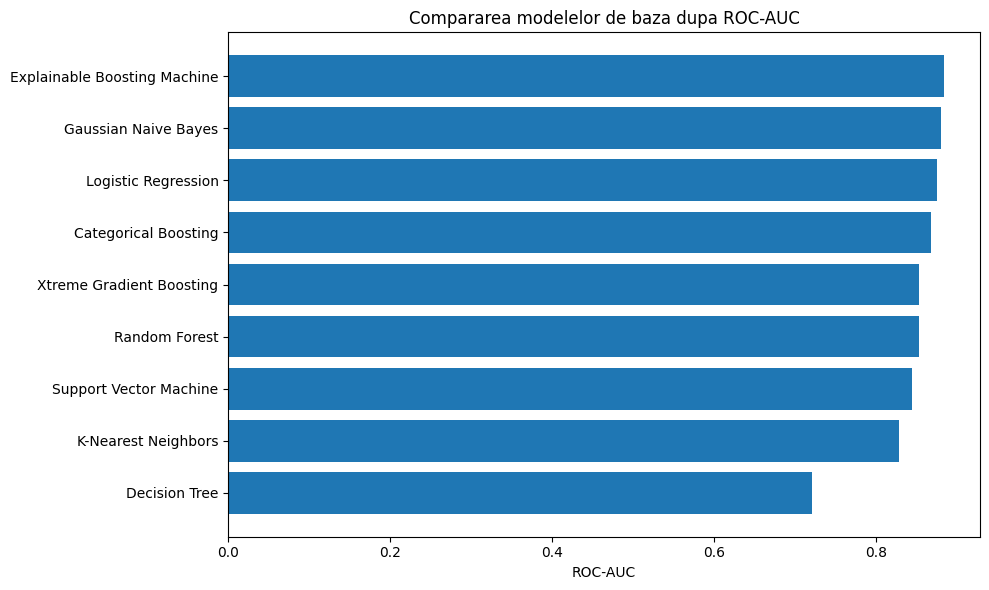

In [83]:
plt.figure(figsize=(10, 6))

plt.barh(
    results_df["Model"],
    results_df["ROC-AUC"]
)

plt.xlabel("ROC-AUC")
plt.title("Compararea modelelor de baza dupa ROC-AUC")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

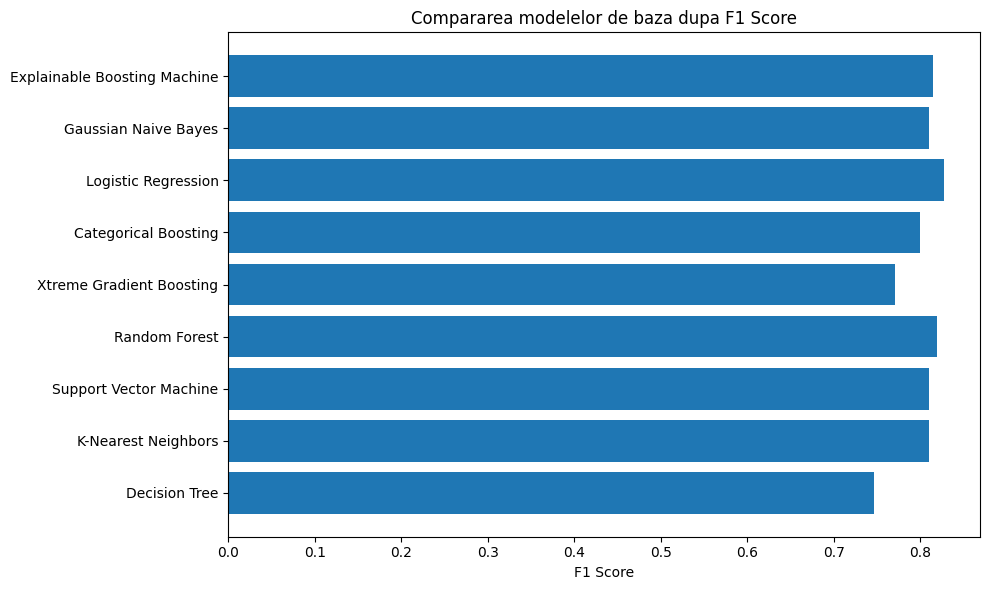

In [84]:
plt.figure(figsize=(10, 6))

plt.barh(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.xlabel("F1 Score")
plt.title("Compararea modelelor de baza dupa F1 Score")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Observații

Pentru realizarea clasamentului final al modelelor de bază a fost utilizată metrica **ROC-AUC**, deoarece aceasta oferă o evaluare mai detaliată decât acuratețea în problemele de clasificare binară. ROC-AUC măsoară capacitatea modelului de a separa corect două clase pentru mai multe praguri de decizie, fiind o alegere potrivită în context medical, unde diferențierea corectă între pacienții cu risc și cei fără risc este importantă.

Pe baza rezultatelor obținute, primele 5 modele selectate pentru etapa de ajustare a hiperparametrilor sunt:

1. Explainable Boosting Machine
2. Gaussian Naive Bayes
3. Logistic Regression
4. Categorical Boosting
5. Xtreme Gradient Boosting

Aceste modele au cele mai bune valori ROC-AUC dintre clasificatorii testați și vor fi analizate în continuare într-o etapă de optimizare.